**Autor**: Juan Alejandro Carrillo Jaimes

**Creación**: 10-08-2026

**Ult Modificación**: 10-08-2026

**Materia**: Mét. Apren Auto para Toma de Decisiones 20262  - A

**Descripción**: Script de entendimiento y preparación de datos sobre el
dataset Wine Quality (UCI). Se realizan actividades de conocimiento de los
datos (tipos de atributo, medidas de centralidad/dispersión, correlación,
balanceo de clases, datos faltantes y atípicos) y actividades de preparación
de los datos derivadas de dichos hallazgos, como paso previo al entrenamiento
de un modelo de clasificación/regresión de la calidad del vino.

**¿De qué trata este dataset?**

Son mediciones de **6497** vinos portugueses (tipo "Vinho Verde", tintos y blancos), tomados en laboratorio. Cada fila del dataset = un vino específico que fue analizado. Para cada vino se midieron:

**11 características fisicoquímicas** (los "atributos de entrada" o features): acidez, azúcar, cloruros, dióxido de azufre, densidad, pH, sulfatos, alcohol, etc. — cosas que se miden con instrumentos de laboratorio, de forma objetiva.
1 calificación de calidad (quality, el "atributo objetivo"): un puntaje del 0 al 10 dado por catadores humanos, evaluando qué tan bueno les pareció el vino.
Además sabemos si cada vino es tinto o blanco (color).

In [70]:
!pip install ucimlrepo -q \
             pyod -q \
             imbalanced-learn -q

In [3]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

# Configuración visual
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

### **Carga del conjunto de datos**

Obtener el dataset directamente desde UCI y dejarlo disponible como dataframes de pandas, listos para trabajar.

In [5]:
# Se descarga el dataset Wine Quality (id=186) desde el repositorio UCI
wine_quality = fetch_ucirepo(id=186)

# Datos en formato de dataframes de pandas
X = wine_quality.data.features   # atributos de entrada
y = wine_quality.data.targets    # atributo objetivo (quality)

# Se consolida un único dataframe para facilitar el análisis exploratorio
data = pd.concat([X, y], axis=1)

In [6]:
# Metadatos generales del dataset (solo los campos relevantes)
meta = wine_quality.metadata

print(f"Nombre del dataset : {meta['name']}")
print(f"N° de instancias   : {meta['num_instances']}")
print(f"N° de atributos    : {meta['num_features']}")
print(f"¿Datos faltantes?  : {meta['has_missing_values']}")
print(f"Tareas asociadas   : {', '.join(meta['tasks'])}")
print(f"URL del repositorio: {meta['repository_url']}")

Nombre del dataset : Wine Quality
N° de instancias   : 4898
N° de atributos    : 11
¿Datos faltantes?  : no
Tareas asociadas   : Classification, Regression
URL del repositorio: https://archive.ics.uci.edu/dataset/186/wine+quality


In [7]:
# Información de las variables
variables_info = wine_quality.variables.dropna(axis=1, how='all')
variables_info

,name,role,type,description,missing_values
0,fixed_acidity,Feature,Continuous,None,no
1,volatile_acidity,Feature,Continuous,None,no
2,citric_acid,Feature,Continuous,None,no
3,residual_sugar,Feature,Continuous,None,no
4,chlorides,Feature,Continuous,None,no
5,free_sulfur_dioxide,Feature,Continuous,None,no
6,total_sulfur_dioxide,Feature,Continuous,None,no
7,density,Feature,Continuous,None,no
8,pH,Feature,Continuous,None,no
9,sulphates,Feature,Continuous,None,no


## Etapa 1: Entendimiento - Conocimiento de los datos

En esta etapa se realizan actividades que permiten conocer las características
del conjunto de datos **sin modificarlo**, con el fin de identificar
situaciones que puedan afectar negativamente el proceso de aprendizaje
(datos faltantes, atípicos, desbalanceo, correlación entre variables, etc.).

### 1.1 Número de muestras y atributos, y tipo de cada atributo

Antes, una aclaración importante sobre color: como tiene `role = "Other"`, la librería `ucimlrepo` **no lo incluye** ni en `X` (que solo trae role=Feature) ni en y (que solo trae role=Target). Por eso, el dataframe **data** actual solo tiene 12 columnas (11 features + quality), sin `color`.

In [9]:
color = wine_quality.data.original['color']
data['color'] = color

# Dimensiones del dataset
n_muestras, n_atributos = data.shape
print(f"Número de muestras : {n_muestras}")
print(f"Número de atributos: {n_atributos - 1}") # sin contar atributo quality

Número de muestras : 6497
Número de atributos: 12


In [10]:
# Tipo de dato de cada atributo (tal como lo interpreta pandas)
tipos = pd.DataFrame({
    'tipo_pandas': data.dtypes,
    'tipo_conceptual': [
        'Categórico (nominal)' if data[col].dtype == 'object'
        else 'Discreto (entero)' if pd.api.types.is_integer_dtype(data[col])
        else 'Continuo'
        for col in data.columns
    ]
})
tipos

,tipo_pandas,tipo_conceptual
fixed_acidity,float64,Continuo
volatile_acidity,float64,Continuo
citric_acid,float64,Continuo
residual_sugar,float64,Continuo
chlorides,float64,Continuo
free_sulfur_dioxide,float64,Continuo
total_sulfur_dioxide,float64,Continuo
density,float64,Continuo
pH,float64,Continuo
sulphates,float64,Continuo


In [33]:
# valores faltantes
print("Total de valores faltantes...\n")
print(data.isnull().sum())

Total de valores faltantes...

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
color                   0
dtype: int64


In [26]:
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


### 1.2 Medidas de centralidad y dispersión por atributo

- Atributos continuos `describe() (media, std, quartiles)`
- `quality` (discreto/ordinal) y `color` (categórico) conteos + gráficos de barras.

In [17]:
atributos_continuos = [col for col in data.columns
                       if data[col].dtype == 'float64']
# Medidas de centralidad y dispersión
data[atributos_continuos].describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile_acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric_acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual_sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free_sulfur_dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total_sulfur_dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


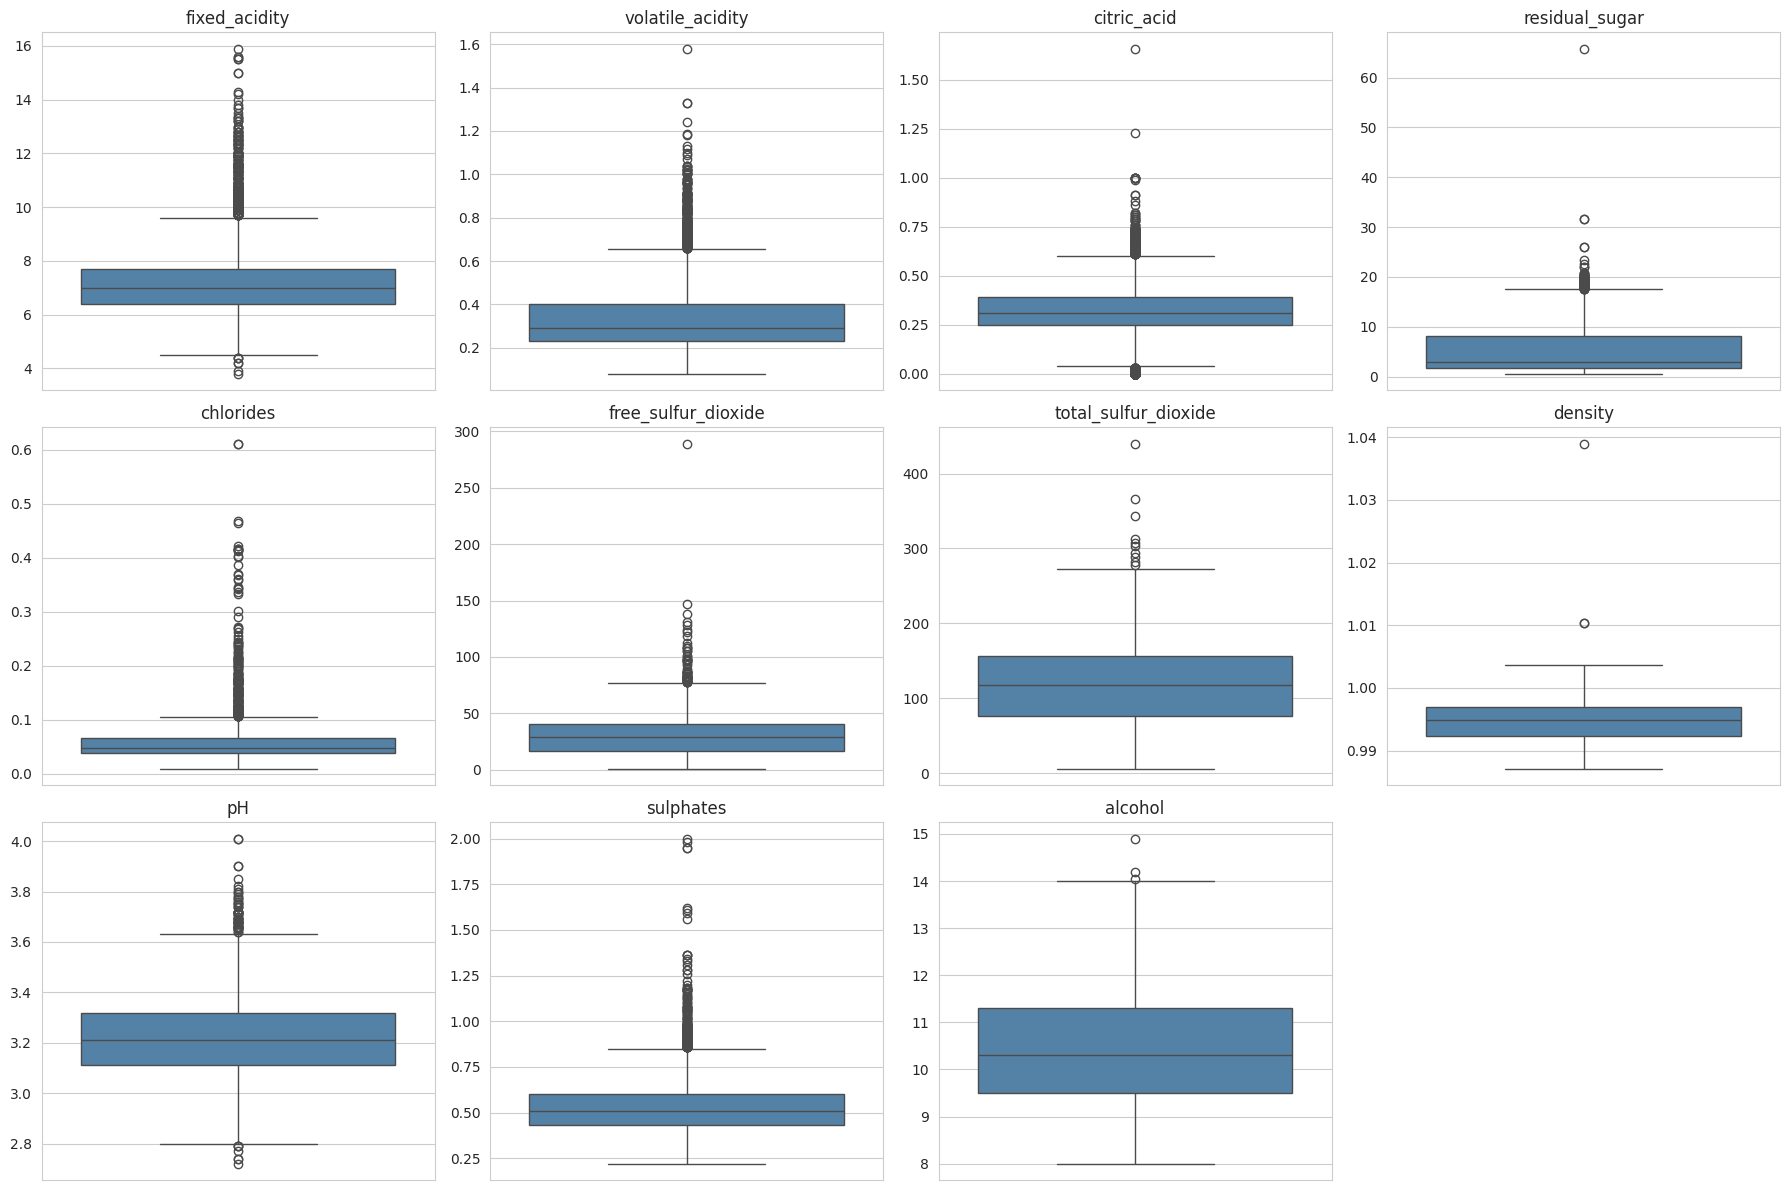

In [18]:
# Boxplots de los atributos continuos
# Se separan en dos figuras por escalas muy distintas
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(atributos_continuos):
    sns.boxplot(y=data[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

# Se ocultan los ejes sobrantes (12 subplots, 11 atributos)
for j in range(len(atributos_continuos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Casi todos los atributos presentan numerosos outliers hacia arriba, un
comportamiento típico de variables fisicoquímicas con distribución sesgada
a la derecha (asimetría positiva): la mayoría de los vinos tiene valores
bajos o moderados y relativamente similares entre sí, mientras que un grupo
minoritario presenta valores considerablemente más altos, que se alejan del
resto y aparecen como outliers en el gráfico.

Este comportamiento se observa principalmente en: `residual_sugar`,
`chlorides`, `free_sulfur_dioxide`, `total_sulfur_dioxide`, `sulphates` y
`citric_acid`, los cuales muestran nubes densas de círculos por encima del
bigote superior.

count    6497.000000
mean        5.818378
std         0.873255
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64

Conteo por valor de calidad:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


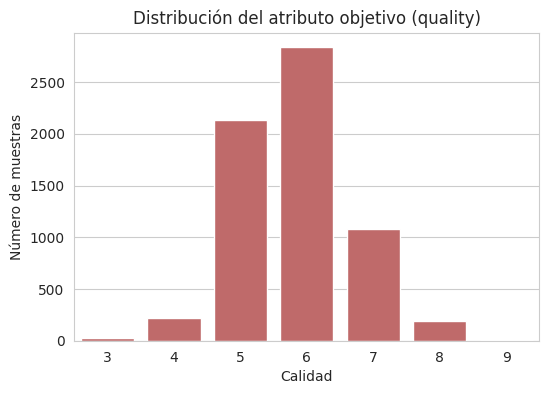

In [19]:
# Medidas de centralidad/dispersión y distribución de 'quality'
print(data['quality'].describe())
print("\nConteo por valor de calidad:")
print(data['quality'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(x='quality', data=data, color='indianred')
plt.title('Distribución del atributo objetivo (quality)')
plt.xlabel('Calidad')
plt.ylabel('Número de muestras')
plt.show()

In [20]:
# Conteo y porcentaje por valor de quality, en formato horizontal
conteo = data['quality'].value_counts().sort_index()
porcentaje = (data['quality'].value_counts(normalize=True).sort_index() * 100).round(2)

resumen_quality = pd.DataFrame({
    'Conteo': conteo,
    'Porcentaje (%)': porcentaje
}).T

resumen_quality

quality,3,4,5,6,7,8,9
Conteo,30.00,216.00,2138.00,2836.00,1079.00,193.00,5.00
Porcentaje (%),0.46,3.32,32.91,43.65,16.61,2.97,0.08


Se observa que la media está en `5.81` y la mediana en `6.0` están muy cerca. Esto es bueno, indica que la calidad (quality) no está muy sesgada.  Así que está ligeramente simétrica. Siin embargo, hay un problema de desbalanceo de clases. En la gráfica anterior se ve como las clases 5 y 6 concentran el `76.56` de los datos. Y el resto de muestras por fuera de estos, apenas tienen unos pocos ejemplares. Este problema supone una oportunidad para aplicar una técnica de balanceo de clases como `undersampling`, `oversampling` o reagrupaciín de clases en categorías diferentes.

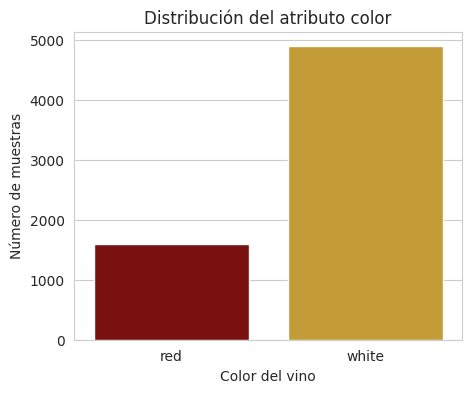

color,red,white
Conteo,1599.00,4898.00
Porcentaje (%),24.61,75.39


In [25]:
# Distribución del atributo 'color'
conteo = data['color'].value_counts().sort_index()
porcentaje = (data['color'].value_counts(normalize=True).sort_index() * 100).round(2)

resumen_color = pd.DataFrame({
    'Conteo': conteo,
    'Porcentaje (%)': porcentaje
}).T



plt.figure(figsize=(5, 4))
sns.countplot(x='color', hue='color', data=data, palette={'red': '#8B0000', 'white': '#DAA520'}, legend=False)
plt.title('Distribución del atributo color')
plt.xlabel('Color del vino')
plt.ylabel('Número de muestras')
plt.show()

resumen_color

El atributo `color` también presenta desbalance: el 75.39% de las muestras
corresponde a vino blanco (4898) y el 24.61% a vino tinto (1599), una
proporción aproximada de 3 a 1. Esta mezcla desigual puede explicar, el sesgo y los outliers observados en algunos atributos
fisicoquímicos (como `residual_sugar`), ya que tinto y blanco suelen tener
perfiles distintos.

#### 1.2.1 Verificación del sesgo: boxplots separados por color

Para confirmar si el sesgo y los outliers observados en algunos atributos
(como `residual_sugar`) se deben a la mezcla de vinos tinto y blanco, se
grafican los boxplots de los atributos continuos separados por el atributo
`color`.

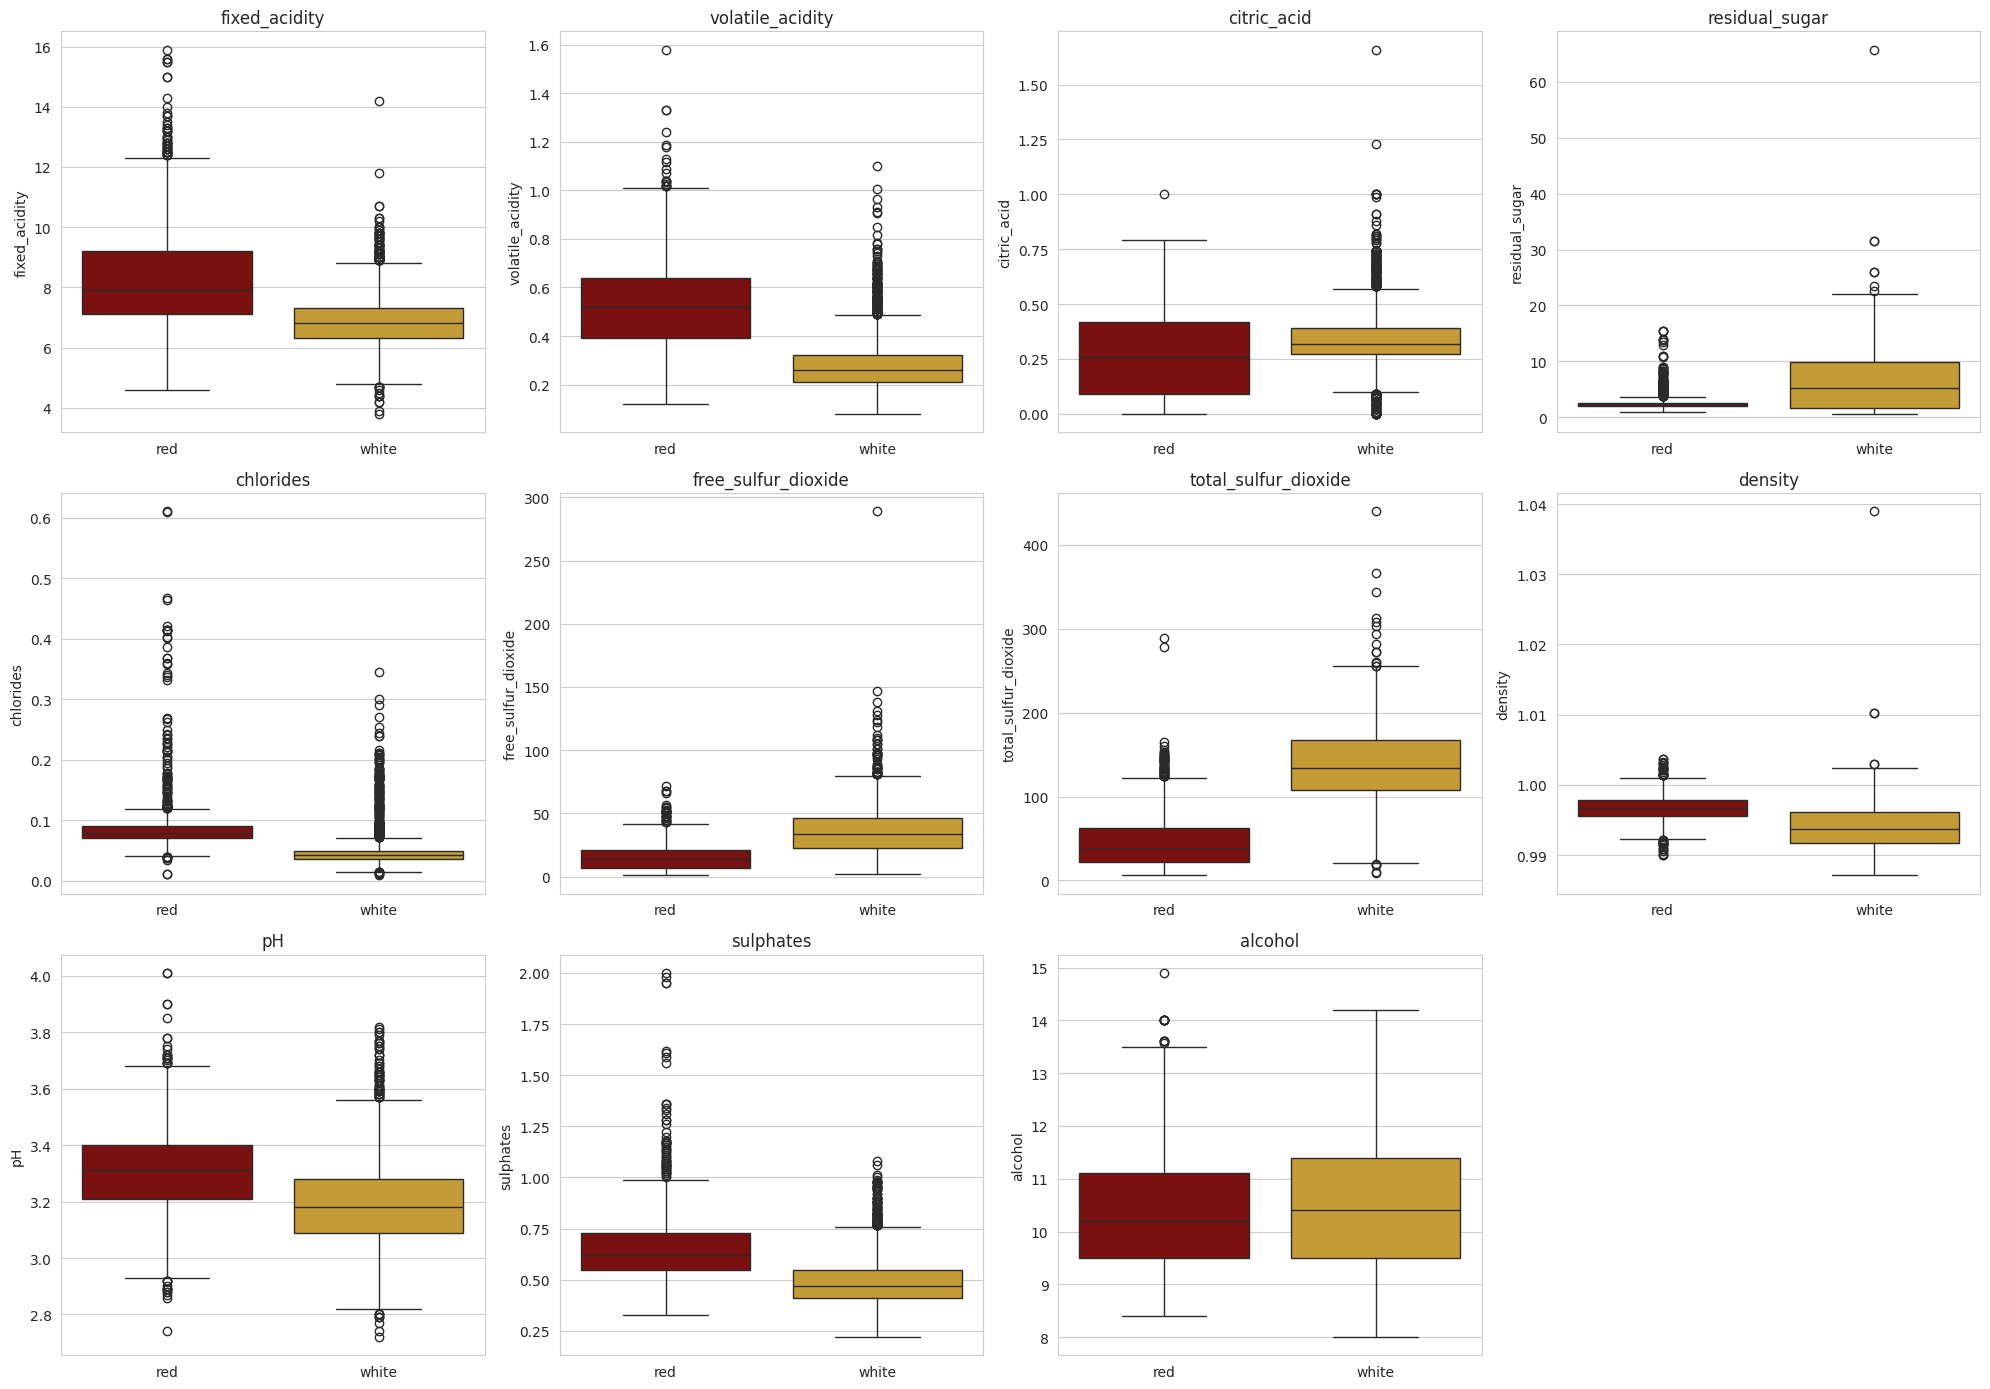

In [27]:
# Boxplots de los atributos continuos, separados por color
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(atributos_continuos):
    sns.boxplot(x='color', y=col, data=data, ax=axes[i],
                hue='color', palette={'red': '#8B0000', 'white': '#DAA520'}, legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Se ocultan los ejes sobrantes
for j in range(len(atributos_continuos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

El color del vino explica parcialmente el sesgo observado
en variables como `residual_sugar`, `free_sulfur_dioxide` y
`total_sulfur_dioxide`, donde tinto y blanco muestran medianas claramente
distintas. Sin embargo, en atributos como `chlorides`, `volatile_acidity`,
`sulphates` y `fixed_acidity`, el sesgo y los outliers persisten dentro de
cada grupo por separado, lo que indica que se trata de una característica
propia de la variable (y no solo un efecto de mezclar tinto y blanco). Esto supone, que los valores atípicos deben analizarse y tratarse con cuidado.

### 1.3 Matriz de correlación entre los atributos de entrada

Se calcula la correlación (Pearson) entre los 11 atributos fisicoquímicos
de entrada, para identificar relaciones lineales fuertes entre ellos
(redundancia de información) que puedan ser relevantes para la etapa de
**preparación de datos**.

In [28]:
# Matriz de correlación de Pearson entre los atributos de entrada
matriz_corr = data[atributos_continuos].corr()
matriz_corr

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
fixed_acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452
volatile_acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640
citric_acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493
residual_sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916
free_sulfur_dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838
total_sulfur_dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029


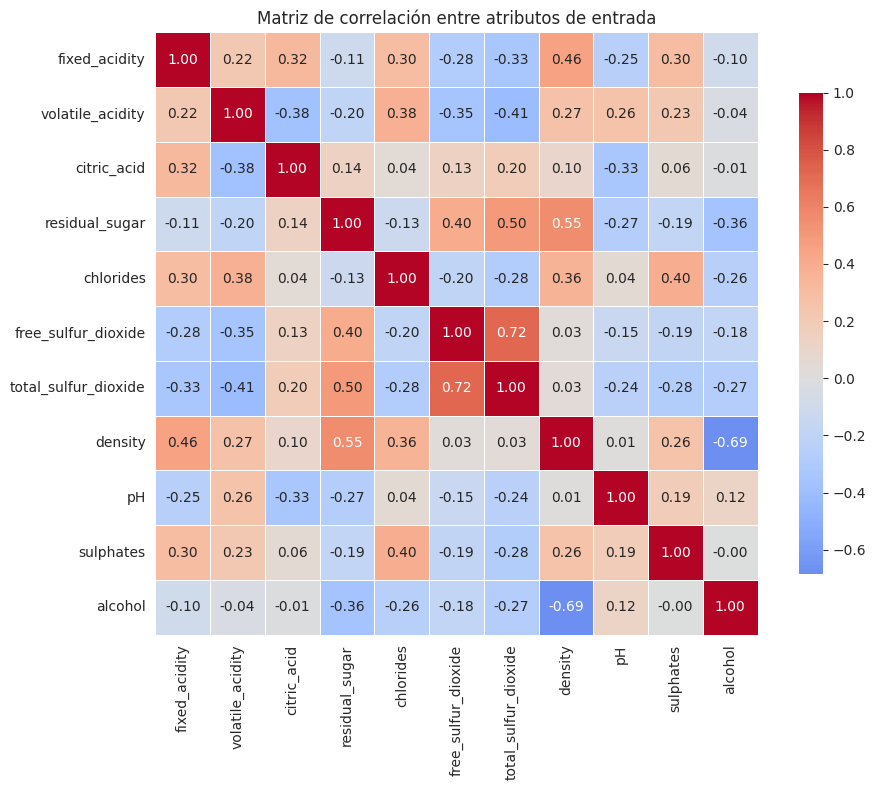

In [34]:
# Mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación entre atributos de entrada')
plt.tight_layout()
plt.show()

In [35]:
# Se listan los pares de atributos con mayor correlación (positiva o negativa),
# excluyendo la diagonal (correlación de un atributo consigo mismo)
corr_pairs = matriz_corr.where(
    ~np.eye(matriz_corr.shape[0], dtype=bool)
).unstack().dropna()

corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]
corr_pairs.sort_values(key=abs, ascending=False).head(10)

,,0
free_sulfur_dioxide,total_sulfur_dioxide,0.720934
alcohol,density,-0.686745
density,residual_sugar,0.552517
residual_sugar,total_sulfur_dioxide,0.495482
density,fixed_acidity,0.458910
total_sulfur_dioxide,volatile_acidity,-0.414476
free_sulfur_dioxide,residual_sugar,0.402871
chlorides,sulphates,0.395593
citric_acid,volatile_acidity,-0.377981
chlorides,volatile_acidity,0.377124


In [37]:
# Dataframe con las variables que presentan alta correlación entre sí
columnas_alta_corr = ['alcohol', 'density', 'free_sulfur_dioxide',
                      'total_sulfur_dioxide']

data_corr_alta = data[columnas_alta_corr]
data_corr_alta.head()

,alcohol,density,free_sulfur_dioxide,total_sulfur_dioxide
0,9.4,0.9978,11.0,34.0
1,9.8,0.9968,25.0,67.0
2,9.8,0.9970,15.0,54.0
3,9.8,0.9980,17.0,60.0
4,9.4,0.9978,11.0,34.0


Ningún par de atributos supera |r| = 0.75, por lo que **no hay evidencia de
multicolinealidad extrema** que obligue a _eliminar variables en esta etapa_.

Sin embargo, sí se identifican varios pares con correlación moderada-alta
(`free_sulfur_dioxide`-`total_sulfur_dioxide`: 0.72, `alcohol`-`density`:
-0.69, `density`-`residual_sugar`: 0.55), lo que indica cierto grado de
redundancia de información entre los 11 atributos originales.

Por ahora, **no se elimina ningún atributo en la etapa de preparación**
únicamente por motivo de correlación; la decisión se dejará para una
eventual etapa de selección de características, en función del modelo
que se use.

### 1.4 Datos faltantes por clase

Se verifica la presencia de valores faltantes en el dataset, tanto de forma
global como desglosada por cada valor del atributo objetivo (`quality`).

In [38]:
# Conteo de valores faltantes por atributo (global)
faltantes = data.isnull().sum()
faltantes_pct = (data.isnull().mean() * 100).round(2)

resumen_faltantes = pd.DataFrame({
    'faltantes': faltantes,
    'porcentaje (%)': faltantes_pct
})
resumen_faltantes

,faltantes,porcentaje (%)
fixed_acidity,0,0.0
volatile_acidity,0,0.0
citric_acid,0,0.0
residual_sugar,0,0.0
chlorides,0,0.0
free_sulfur_dioxide,0,0.0
total_sulfur_dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


In [41]:
# Conteo de valores faltantes por atributo, desglosado por clase (quality)
faltantes_por_clase = data.set_index('quality').isnull().groupby(level=0).sum()
faltantes_por_clase

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,color
quality,,,,,,,,,,,,
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0


El dataset **no presenta valores faltantes en ningún atributo**, ni de forma global ni al desglosar por clase de `quality`.No será necesario aplicar técnicas de imputación en la etapa de
preparación de datos.

### 1.5 Identificación de datos atípicos por clase

Se utiliza la librería `pyod` (Python Outlier Detection) para identificar
observaciones atípicas de forma multivariada (considerando simultáneamente
los 11 atributos fisicoquímicos), a diferencia de los boxplots anteriores
que evaluaban cada atributo por separado. Se aplica el algoritmo
**Isolation Forest**, y se reporta el número de atípicos detectados por
cada clase del atributo objetivo (`quality`).

In [44]:
from pyod.models.iforest import IForest

In [46]:
# Se estandarizan los atributos continuos antes de aplicar el detector
# (Isolation Forest no lo exige estrictamente, pero ayuda a que todas las
# variables aporten en igualdad de condiciones)
from sklearn.preprocessing import StandardScaler

X_continuas = data[atributos_continuos]
X_scaled = StandardScaler().fit_transform(X_continuas)
X_scaled

array([[ 0.14247327,  2.18883292, -2.19283252, ...,  1.81308951,
         0.19309677, -0.91546416],
       [ 0.45103572,  3.28223494, -2.19283252, ..., -0.11507303,
         0.99957862, -0.58006813],
       [ 0.45103572,  2.55330026, -1.91755268, ...,  0.25811972,
         0.79795816, -0.58006813],
       ...,
       [-0.55179227, -0.6054167 , -0.88525328, ..., -1.42124765,
        -0.47897144, -0.91546416],
       [-1.32319841, -0.30169391, -0.12823371, ...,  0.75571005,
        -1.016626  ,  1.9354021 ],
       [-0.93749534, -0.78765037,  0.42232597, ...,  0.25811972,
        -1.41986693,  1.09691202]])

In [47]:
detector = IForest(contamination=0.1, random_state=42)
detector.fit(X_scaled)

IForest(behaviour='old', bootstrap=False, contamination=0.1, max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=42,
    verbose=0)

In [49]:
# 0 = normal, 1 = atípico
data['es_atipico'] = detector.labels_
print(f"Total de datos atípicos detectados: {data['es_atipico'].sum()} de {len(data)}")

Total de datos atípicos detectados: 650 de 6497


In [50]:
# Número de datos atípicos por clase (quality)
atipicos_por_clase = data.groupby('quality')['es_atipico'].agg(
    total_muestras='count',
    n_atipicos='sum'
)
atipicos_por_clase['porcentaje (%)'] = (
    atipicos_por_clase['n_atipicos'] / atipicos_por_clase['total_muestras'] * 100
).round(2)

atipicos_por_clase

,total_muestras,n_atipicos,porcentaje (%)
quality,,,
3,30,18,60.00
4,216,34,15.74
5,2138,243,11.37
6,2836,249,8.78
7,1079,89,8.25
8,193,17,8.81
9,5,0,0.00


#### 1.5.1 Exploración detallada de las clases minoritarias (quality 3 y 4)

In [52]:
# Se seleccionan las muestras de quality 3 y quality 4 por separado
data_q3 = data[data['quality'] == 3]
data_q4 = data[data['quality'] == 4]

In [53]:
print("Quality = 3")
data_q3[atributos_continuos].describe()

Quality = 3


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,30.000000,30.000000,30.00000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,7.853333,0.517000,0.28100,5.140000,0.077033,39.216667,122.033333,0.995744,3.257667,0.506333,10.215000
std,1.747853,0.341913,0.17351,4.730721,0.062014,59.990327,112.141762,0.002833,0.213246,0.126994,1.106497
min,4.200000,0.170000,0.00000,0.700000,0.022000,3.000000,9.000000,0.991100,2.870000,0.280000,8.000000
25%,6.800000,0.252500,0.21250,1.650000,0.038750,5.250000,30.000000,0.993750,3.140000,0.407500,9.625000
50%,7.450000,0.415000,0.33000,3.150000,0.055000,17.000000,102.500000,0.995900,3.245000,0.505000,10.150000
75%,8.575000,0.632500,0.39500,7.800000,0.081000,37.375000,193.250000,0.998060,3.415000,0.565000,11.000000
max,11.800000,1.580000,0.66000,16.200000,0.267000,289.000000,440.000000,1.000800,3.630000,0.860000,12.600000


In [54]:
print("\nQuality = 4")
data_q4[atributos_continuos].describe()


Quality = 4


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.00000,216.000000,216.000000
mean,7.288889,0.457963,0.272315,4.153704,0.060056,20.636574,103.432870,0.994833,3.23162,0.505648,10.180093
std,1.264825,0.229311,0.182079,3.812136,0.047068,18.865524,61.282714,0.002475,0.18839,0.164434,0.985923
min,4.600000,0.110000,0.000000,0.700000,0.013000,3.000000,7.000000,0.989200,2.74000,0.250000,8.400000
25%,6.400000,0.280000,0.140000,1.400000,0.040750,8.000000,55.000000,0.993030,3.09000,0.400000,9.400000
50%,7.000000,0.380000,0.260000,2.200000,0.050500,15.000000,102.000000,0.994995,3.22000,0.485000,10.000000
75%,8.000000,0.610000,0.372500,5.600000,0.067000,27.250000,151.000000,0.996655,3.35000,0.570000,10.900000
max,12.500000,1.130000,1.000000,17.550000,0.610000,138.500000,272.000000,1.001000,3.90000,2.000000,13.500000


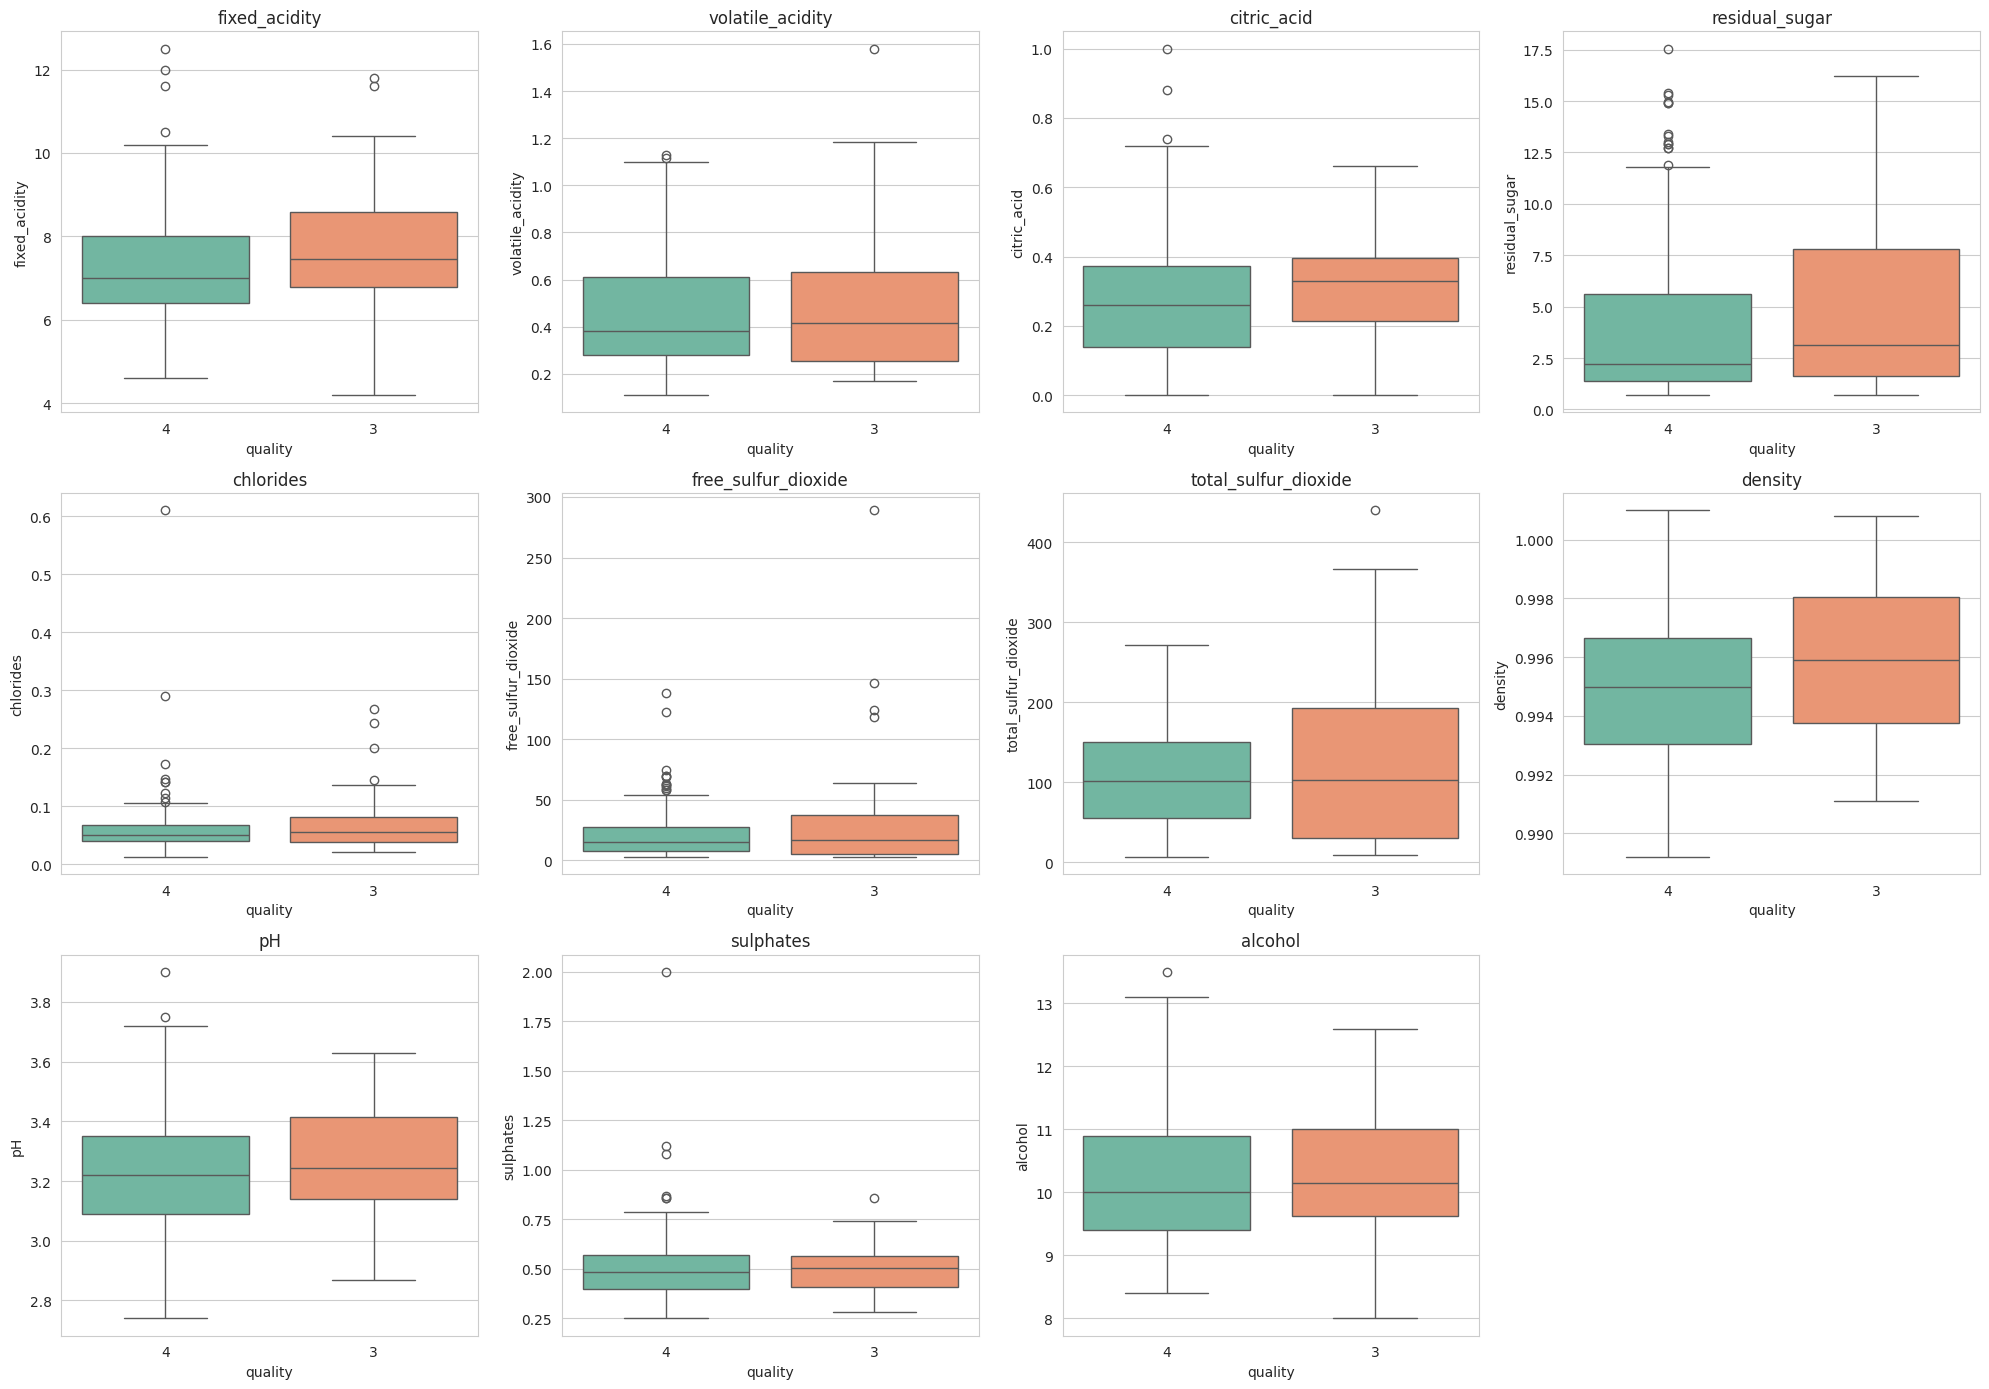

In [55]:
# Subconjunto combinado (solo quality 3 y 4), para comparar lado a lado
data_q3_q4 = data[data['quality'].isin([3, 4])].copy()
data_q3_q4['quality'] = data_q3_q4['quality'].astype(str)  # para que se trate como categoría

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(atributos_continuos):
    sns.boxplot(x='quality', y=col, data=data_q3_q4, ax=axes[i],
                hue='quality', palette='Set2', legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('quality')

for j in range(len(atributos_continuos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

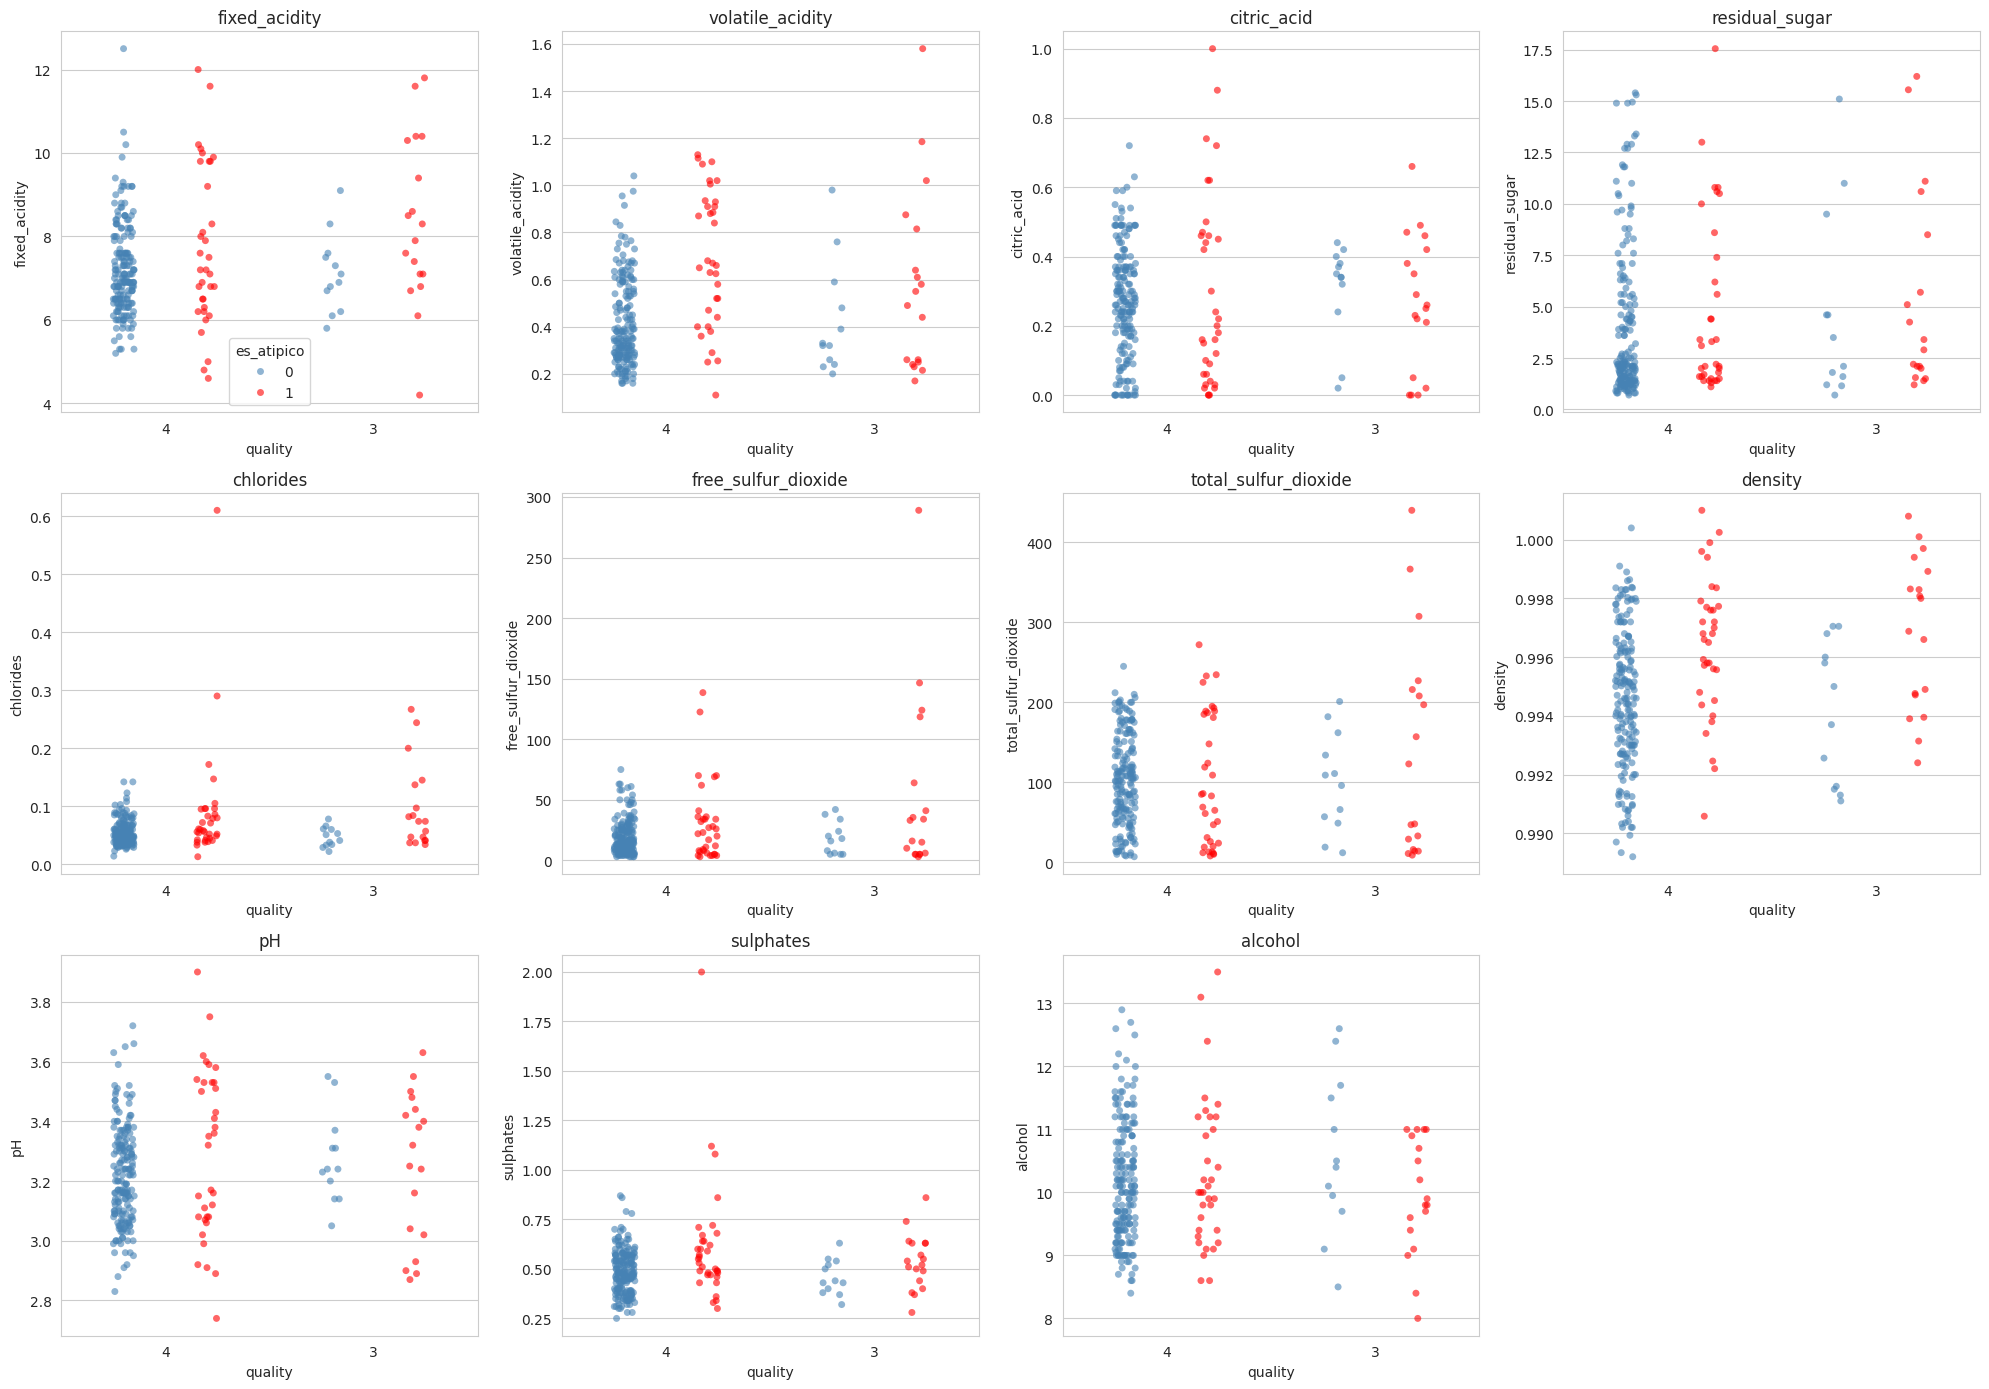

In [56]:
# Igual al anterior, pero coloreando los puntos según si fueron marcados como atípicos
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(atributos_continuos):
    sns.stripplot(x='quality', y=col, data=data_q3_q4, ax=axes[i],
                  hue='es_atipico', palette={0: 'steelblue', 1: 'red'},
                  dodge=True, alpha=0.6, legend=(i == 0))
    axes[i].set_title(col)
    axes[i].set_xlabel('quality')

for j in range(len(atributos_continuos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Conclusión:** al desagregar visualmente los datos atípicos dentro de las
clases 3 y 4, se observa que estos NO se distribuyen al azar dentro de cada
clase, sino que presentan un perfil fisicoquímico sistemáticamente distinto:
mayor `volatile_acidity`, mayor `density`, mayor `pH` y menor `alcohol`
respecto a las muestras "normales" de la misma clase.

Esto sugiere que, dentro de las clases minoritarias, el detector no está
simplemente marcando "ruido aleatorio", sino identificando un subperfil
químico específico (posiblemente vinos con defectos de fermentación o
elaboración, dada la asociación conocida entre alta acidez volátil y
defectos del vino). Esto refuerza la recomendación de NO eliminar estos
atípicos sin un análisis más profundo, ya que podrían representar
información real y relevante para distinguir vinos de baja calidad, más
que errores de captura de datos.

### 1.6 Conclusión general — Etapa 1: Entendimiento de los datos

El dataset tiene 6497 muestras, 11 atributos continuos de entrada, el
atributo objetivo `quality` (discreto, 3-9) y el atributo `color`
(categórico). No presenta datos faltantes.

Los hallazgos más relevantes para la etapa de preparación son:

- **Desbalanceo fuerte en `quality`**: las clases 5 y 6 concentran ~77%
  de los datos; las clases extremas (3 y 9) son casi inexistentes.
- **Atípicos concentrados en las clases minoritarias**: de los 650
  atípicos detectados con `IForest` (10%), el porcentaje sube hasta 60%
  en `quality=3`, frente a ~8-11% en las clases mayoritarias. Esto está
  ligado al desbalanceo, no son errores de medición.
- **Sin multicolinealidad extrema** entre atributos de entrada (máx.
  |r|=0.72), por lo que no se elimina ningún atributo por esta razón.

En consecuencia, en la Etapa 2 se trabajará principalmente el **balanceo
de clases** y **no se eliminarán los atípicos de forma automática**, ya
que agravaría el desbalanceo. Además, se codificará `color` y se
escalarán los atributos continuos.

## Etapa 2: Preparación de los datos

De acuerdo con lo observado en la Etapa 1, se definen las siguientes
actividades para modificar el conjunto de datos y dejarlo listo para un
futuro proceso de entrenamiento:

1. Codificar el atributo categórico `color`.
2. Escalar los atributos continuos de entrada.
3. Balancear el atributo objetivo `quality`.

No se realiza imputación de datos faltantes (no existen) ni eliminación
de datos atípicos (su alta concentración en las clases minoritarias
agravaría el desbalanceo ya identificado).

### 2.1 Codificación del atributo categórico `color`

Uso `.map({'red': 0, 'white': 1})` en vez de **LabelEncoder** porque, siendo binaria, es más explícito y evita ambigüedad sobre qué valor quedó asignado a cada categoría.

In [57]:
# Se trabaja sobre una copia, para no perder el dataframe original de la Etapa 1
data_prep = data.drop(columns=['es_atipico']).copy()

# 'color' es binaria (red/white), se codifica con valores 0/1
data_prep['color'] = data_prep['color'].map({'red': 0, 'white': 1})

data_prep[['color']].value_counts()

,count
color,
1,4898
0,1599


### 2.2 Escalado de los atributos continuos

Dado que los 11 atributos fisicoquímicos tienen escalas muy distintas
(por ejemplo, `total_sulfur_dioxide` llega a valores de cientos, mientras
`density` se mueve siempre cerca de 1.0), se aplica estandarización
(`StandardScaler`) para llevarlos a media 0 y desviación estándar 1. Esto
evita que los atributos con mayor magnitud numérica dominen artificialmente
en algoritmos sensibles a la escala (distancias, gradiente, regularización).

El atributo objetivo `quality` y el atributo `color` (ya codificado como
0/1) no se escalan.

In [66]:
# datos continuos no escalados
data_prep[atributos_continuos].sample(5, random_state=42)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
3103,7.0,0.17,0.74,12.8,0.045,24.0,126.0,0.99420,3.26,0.38,12.2
1419,7.7,0.64,0.21,2.2,0.077,32.0,133.0,0.99560,3.27,0.45,9.9
4761,6.8,0.39,0.34,7.4,0.020,38.0,133.0,0.99212,3.18,0.44,12.0
4690,6.3,0.28,0.47,11.2,0.040,61.0,183.0,0.99592,3.12,0.51,9.5
4032,7.4,0.35,0.20,13.9,0.054,63.0,229.0,0.99888,3.11,0.50,8.9


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Se escalan únicamente los 11 atributos continuos de entrada
data_prep[atributos_continuos] = scaler.fit_transform(data_prep[atributos_continuos])

data_prep.sample(5, random_state=42)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
3103,-0.166089,-1.030629,2.899845,1.546371,-0.314975,-0.367664,0.181456,-0.165631,0.258120,-1.016626,1.432308,8,1
1419,0.373895,1.824366,-0.747613,-0.681719,0.598504,0.083090,0.305311,0.301278,0.320319,-0.546178,-0.496219,5,0
4761,-0.320370,0.305752,0.147046,0.411306,-1.028631,0.421155,0.305311,-0.859324,-0.239471,-0.613385,1.264610,7,1
4690,-0.706073,-0.362438,1.041706,1.210056,-0.457706,1.717074,1.189993,0.408001,-0.612663,-0.142937,-0.831615,6,1
4032,0.142473,0.062773,-0.816433,1.777588,-0.058059,1.829762,2.003900,1.395180,-0.674862,-0.210144,-1.334709,6,1


In [68]:
# Verificación: media ≈ 0 y desviación estándar ≈ 1 en los atributos escalados
data_prep[atributos_continuos].describe().loc[['mean', 'std']].round(2)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
mean,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Se verifica que los 11 atributos continuos quedaron
estandarizados correctamente (media ≈ 0, desviación estándar = 1),
dejando a todos en igualdad de condiciones para el modelado futuro.

### 2.3 Reagrupación del atributo objetivo

Dado el fuerte desbalanceo entre las 7 clases originales de `quality`
(algunas con menos de 10 muestras), se reagrupan en 3 categorías más
representativas:

- **Baja** (quality 3-4)
- **Media** (quality 5-6)
- **Alta** (quality 7-9)

Esta reagrupación conserva el orden natural de la calidad y produce
clases con un tamaño mínimo razonable para su posterior balanceo.

In [69]:
def categorizar_quality(q):
    if q <= 4:
        return 'baja'
    elif q <= 6:
        return 'media'
    else:
        return 'alta'

data_prep['quality_cat'] = data_prep['quality'].apply(categorizar_quality)

# Se elimina el 'quality' original de 7 clases (queda 'quality_cat' como nuevo objetivo)
data_prep = data_prep.drop(columns=['quality'])

conteo_cat = data_prep['quality_cat'].value_counts()
porcentaje_cat = (data_prep['quality_cat'].value_counts(normalize=True) * 100).round(2)

pd.DataFrame({'conteo': conteo_cat, 'porcentaje (%)': porcentaje_cat})

,conteo,porcentaje (%)
quality_cat,,
media,4974,76.56
alta,1277,19.66
baja,246,3.79


### 2.4 Balanceo del atributo objetivo (`quality_cat`)

Se aplica una estrategia combinada para llevar las 3 categorías a un
tamaño intermedio (~2000 muestras cada una):

- **Undersampling** en la clase "media" (4974 → ~2000), eliminando
  muestras al azar.
- **SMOTE (oversampling sintético)** en las clases "baja" (246 → ~2000)
  y "alta" (1277 → ~2000), generando muestras sintéticas por interpolación
  entre vecinos cercanos.

Esto evita tanto la pérdida masiva de datos (undersampling puro) como la
sobre-generación de sintéticos en una clase con muy pocos datos originales
(SMOTE puro llevando "baja" a 4974, un factor ~20x).

In [71]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Atributos de entrada (continuos + color) y objetivo categórico
X = data_prep.drop(columns=['quality_cat'])
y = data_prep['quality_cat']

print("Distribución original:")
print(y.value_counts())

Distribución original:
quality_cat
media    4974
alta     1277
baja      246
Name: count, dtype: int64


In [72]:
# Tamaño objetivo intermedio para las 3 clases
n_objetivo = 2000

# 1. Undersampling: reduce 'media' a n_objetivo
undersample = RandomUnderSampler(
    sampling_strategy={'media': n_objetivo}, random_state=42
)

# 2. SMOTE: aumenta 'baja' y 'alta' a n_objetivo
oversample = SMOTE(
    sampling_strategy={'baja': n_objetivo, 'alta': n_objetivo}, random_state=42
)

pipeline_balanceo = ImbPipeline(steps=[
    ('under', undersample),
    ('over', oversample)
])

X_balanceado, y_balanceado = pipeline_balanceo.fit_resample(X, y)

print("Distribución después del balanceo:")
print(y_balanceado.value_counts())

Distribución después del balanceo:
quality_cat
alta     2000
baja     2000
media    2000
Name: count, dtype: int64


In [73]:
# Se reconstruye el dataframe final ya balanceado
data_balanceado = X_balanceado.copy()
data_balanceado['quality_cat'] = y_balanceado

print(f"Dimensiones finales: {data_balanceado.shape}")
data_balanceado.head()

Dimensiones finales: (6000, 13)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,color,quality_cat
0,0.065333,1.885110,-2.192833,-0.891916,0.255949,-0.874763,-1.676376,-0.032228,1.066704,-0.411765,-0.412370,0,alta
1,0.451036,1.459898,-2.055193,-0.723758,0.484319,-1.212828,-1.729457,0.701486,0.880108,0.260304,-0.831615,0,alta
2,0.991020,-0.362438,1.661085,-0.765798,1.026697,0.252123,-0.225498,0.734837,0.506915,1.470026,0.006875,0,alta
3,0.682458,0.245007,-0.265874,-0.702739,0.284496,-0.987451,-1.517133,0.701486,0.071523,1.335613,-0.663917,0,alta
4,0.219614,1.095431,-1.091713,-0.744778,0.826874,-1.043796,-1.428665,0.701486,1.004505,0.596338,-0.831615,0,alta


In [74]:
data_balanceado.to_csv('wine_quality_balanced.csv', index=False)

**Conclusión:** el atributo objetivo `quality_cat` quedó balanceado con
2000 muestras por categoría (baja/media/alta), para un total de 6000
registros. Se combinó undersampling en la clase mayoritaria ("media":
4974 → 2000) con oversampling sintético vía SMOTE en las clases
minoritarias ("baja": 246 → 2000, "alta": 1277 → 2000), evitando tanto
la pérdida masiva de datos reales como la sobre-generación artificial de
sintéticos a partir de muy pocas muestras originales.

### 2.5 Conclusión general — Etapa 2: Preparación de los datos

El dataset final (`data_balanceado`) contiene 6000 muestras y 12 atributos
de entrada (11 continuos estandarizados + `color` codificado), con el
atributo objetivo `quality_cat` (baja/media/alta) perfectamente balanceado.

Este conjunto de datos queda listo para una futura etapa de modelado, que
no se aborda en este entregable.